In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Merge Relational Databases

In [3]:
df_customers = pd.read_csv('../data/olist_customers_dataset.csv')
df_orders = pd.read_csv('../data/olist_orders_dataset.csv')
merged_df = pd.merge(df_customers, df_orders, on='customer_id', how='inner')
merged_df.to_csv('olist_customers_and_orders_merged.csv', index=False)

# 2. Data Preprocessing

In [7]:
print("Rows:    ", merged_df.shape[0])
print("Columns: ", merged_df.shape[1])
print("Data types of dataset:")
print(merged_df.dtypes)
print("Missing values of dataset:")
print(merged_df.isnull().sum())

Rows:     99441
Columns:  12
Data types of dataset:
customer_id                        str
customer_unique_id                 str
customer_zip_code_prefix         int64
customer_city                      str
customer_state                     str
order_id                           str
order_status                       str
order_purchase_timestamp           str
order_approved_at                  str
order_delivered_carrier_date       str
order_delivered_customer_date      str
order_estimated_delivery_date      str
dtype: object
Missing values of dataset:
customer_id                         0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_deliv

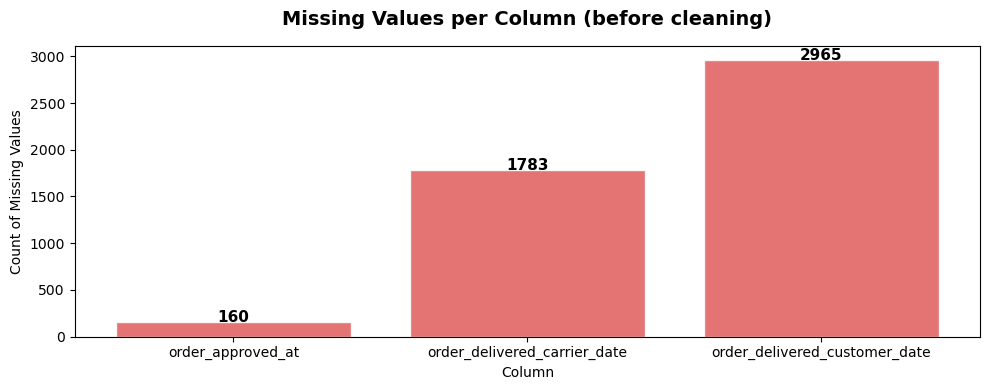

In [10]:
# Visual overview of missing data
fig, ax = plt.subplots(figsize=(10, 4))
missing = merged_df.isnull().sum()
missing = missing[missing > 0]
bars = ax.bar(missing.index, missing.values, color='#E05C5C', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title("Missing Values per Column (before cleaning)", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Count of Missing Values")
ax.set_xlabel("Column")
plt.tight_layout()
plt.show()